<a href="https://colab.research.google.com/drive/1Bl5o9aLFjoXLF5qDD1napqzNpbBfHMg7?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CE 400/500: AI for Chemical Engineers
# Hands-on: Linear Regression for Wine Quality
Instructor: Kaihang Shi, Assistant Professor of Chemical & Biological Engineering at the University at Buffalo

**Learning objectives:**
we will introduce many basic concepts of ML using the example of linear regression model.




**References on Portuguese red wine quality dataset:**
- URL: https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv
- Dataset website: https://archive.ics.uci.edu/dataset/186/wine+quality

**References and further readings on ML:**
* [Google Crash Course: Linear Regression](https://developers.google.com/machine-learning/crash-course/linear-regression)
* [Google Crash Course: Data](https://developers.google.com/machine-learning/crash-course/numerical-data)
* [Red Wine Quality : Linear Regression](https://www.kaggle.com/code/gauravduttakiit/red-wine-quality-linear-regression/notebook)
* K. Shi, Z. Li, D.M. Anstine, D. Tang, C.M. Colina, D.S. Sholl, J.I. Siepmann, and R.Q. Snurr, “Two-Dimensional Energy Histograms as Features for Machine Learning to Predict Adsorption in Diverse Nanoporous Materials,” J. Chem. Theory Comput. 19(14), 4568-4583 (2023).

## 1. Dataset


### 1.1 Understand Your Data
Let's try to understand our dataset first. We will directly download the dataset from UCI. The file uses semicolon (`;`) as a delimiter.

In [ ]:
import pandas as pd
import numpy as np

# for reproducibility of the work
np.random.seed(0)

# Download and read the dataset
wine = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv", sep=';')
wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


We recommend evaluating potential features and labels mathematically, gathering basic statistics such as:

* mean and median
* standard deviation
* the values at the quartile divisions: the 0th, 25th, 50th, 75th, and 100th percentiles. The 0th percentile is the minimum value of this column; the 100th percentile is the maximum value of this column. (The 50th percentile is the median.)

In [ ]:
wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [ ]:
wine.shape

(1599, 12)

Let's check null entries and duplicate rows in the dataset:

In [ ]:
#check null entries and duplicate rows
print(wine.isnull().sum())
print(f"Number of duplicate rows: {wine.duplicated().sum()}")

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
Number of duplicate rows: 240


Let's see these duplicate rows.

In [ ]:
all_duplicates = wine[wine.duplicated(keep=False)]
display(all_duplicates)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
9,7.5,0.500,0.36,6.1,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
11,7.5,0.500,0.36,6.1,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
22,7.9,0.430,0.21,1.6,0.106,10.0,37.0,0.99660,3.17,0.91,9.5,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1567,7.2,0.695,0.13,2.0,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1579,6.2,0.560,0.09,1.7,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5
1581,6.2,0.560,0.09,1.7,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5
1592,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6


OK. Let's remove these duplicate rows and prepare a new dataset.

In [ ]:
wine_unique = wine.drop_duplicates().reset_index(drop=True)
print(f"Number of duplicate rows: {wine_unique.duplicated().sum()}")
wine_unique

Number of duplicate rows: 0


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1354,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1355,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1356,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1357,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


### 1.2 Data Split
Let's split the entire dataset into training and test sets for now. We will discuss validation set later.

In [ ]:
from sklearn.model_selection import train_test_split

# data spliting into training and testing, set random state to ensure reproducibility
df_train,df_test=train_test_split(wine_unique,train_size=0.8,test_size=0.2,random_state=100)

In [ ]:
print(df_train.info())
print(df_train.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 1087 entries, 1271 to 792
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1087 non-null   float64
 1   volatile acidity      1087 non-null   float64
 2   citric acid           1087 non-null   float64
 3   residual sugar        1087 non-null   float64
 4   chlorides             1087 non-null   float64
 5   free sulfur dioxide   1087 non-null   float64
 6   total sulfur dioxide  1087 non-null   float64
 7   density               1087 non-null   float64
 8   pH                    1087 non-null   float64
 9   sulphates             1087 non-null   float64
 10  alcohol               1087 non-null   float64
 11  quality               1087 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 110.4 KB
None
(1087, 12)


In [ ]:
print(df_test.info())
print(df_test.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 272 entries, 1335 to 213
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         272 non-null    float64
 1   volatile acidity      272 non-null    float64
 2   citric acid           272 non-null    float64
 3   residual sugar        272 non-null    float64
 4   chlorides             272 non-null    float64
 5   free sulfur dioxide   272 non-null    float64
 6   total sulfur dioxide  272 non-null    float64
 7   density               272 non-null    float64
 8   pH                    272 non-null    float64
 9   sulphates             272 non-null    float64
 10  alcohol               272 non-null    float64
 11  quality               272 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 27.6 KB
None
(272, 12)


### 1.3 Data Normalization
The goal of normalization is to transform features to be on a similar scale (e.g., from 0 to 1) so that the model can be trained more effectively. The following [figure](https://stats.stackexchange.com/questions/322822/how-normalizing-helps-to-increase-the-speed-of-the-learning) nicely illustrates why the normalization is needed: if features are not normalized, those with larger values (e.g., total sulfur dioxide) can dominate the updates during the optimization process (e.g., when using [gradient descent](https://en.wikipedia.org/wiki/Gradient_descent)).

<div>
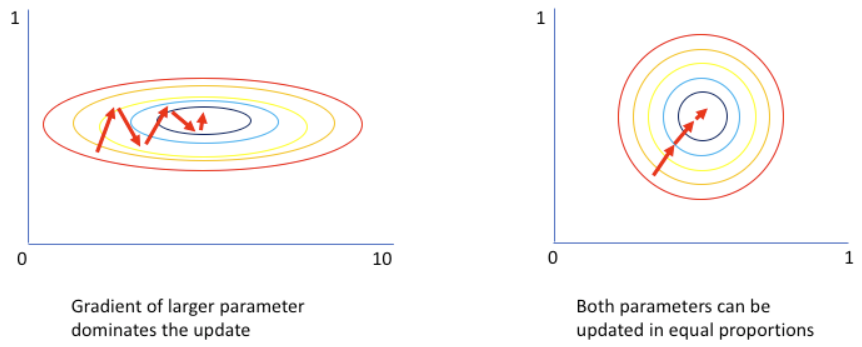
</div>

Normalization provides the following major benefits:

* Helps models converge more quickly during training. When different features have different ranges, gradient descent can "bounce" and slow convergence. That said, more advanced optimizers like Adagrad and Adam protect against this problem by changing the effective learning rate over time.
* Helps the model learn appropriate weights for each feature. Without feature scaling, the model pays too much attention to features with wide ranges and not enough attention to features with narrow ranges.

We recommend normalizing numeric features covering distinctly different ranges (for example, total sulfur dioxide and chlorides). We also recommend normalizing a single numeric feature that covers a wide range, such as total sulfur dioxide.

Popular normalization methods include:
| Normalization technique | Formula | When to use |
|--------------------------|---------|-------------|
| Linear scaling | $$x' = \dfrac{x - x_{min}}{x_{max} - x_{min}}$$ | When the feature is mostly uniformly distributed across range. **Flat-shaped** |
| Z-score scaling | $$x' = \dfrac{x - \mu}{\sigma}$$ | When the feature is normally distributed (peak close to mean). **Bell-shaped** |
| Log scaling | $$x' = \log(x)$$ | When the feature distribution is heavily skewed on at least either side of tail. **Heavy Tail-shaped** |


Let's do Z-score scaling here.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X_train = df_train.drop('quality', axis=1)
y_train = df_train['quality']
X_test = df_test.drop('quality', axis=1)
y_test = df_test['quality']

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit on training data only (to avoid data leakage), transform testing
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Optionally, convert back to DataFrame for convenience
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.describe()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1.087000e+03,1.087000e+03,1.087000e+03,1.087000e+03,1.087000e+03,1.087000e+03,1.087000e+03,1.087000e+03,1.087000e+03,1.087000e+03,1.087000e+03
mean,-4.592054e-16,1.940592e-16,3.595202e-17,3.039580e-16,1.209295e-16,1.487106e-16,-2.451274e-17,5.964768e-17,2.073778e-15,-4.232534e-16,7.656147e-16
std,1.000460e+00,1.000460e+00,1.000460e+00,1.000460e+00,1.000460e+00,1.000460e+00,1.000460e+00,1.000460e+00,1.000460e+00,1.000460e+00,1.000460e+00
min,-2.067495e+00,-1.998159e+00,-1.372559e+00,-1.242123e+00,-1.474163e+00,-1.441902e+00,-1.227155e+00,-3.541793e+00,-3.674637e+00,-1.863536e+00,-1.872286e+00
25%,-6.881427e-01,-7.554421e-01,-9.217366e-01,-4.700797e-01,-3.604412e-01,-7.724021e-01,-7.485711e-01,-5.833011e-01,-6.410501e-01,-6.248048e-01,-8.562918e-01
50%,-2.283587e-01,-5.303702e-02,-7.018323e-02,-2.384668e-01,-1.876223e-01,-1.985448e-01,-2.699875e-01,-1.624163e-04,4.394008e-03,-2.306629e-01,-3.021132e-01
75%,5.187903e-01,5.953369e-01,7.813702e-01,7.035037e-02,4.280284e-02,5.665983e-01,5.077108e-01,5.936760e-01,5.852937e-01,3.887029e-01,6.215178e-01
max,4.369481e+00,5.674266e+00,3.636579e+00,8.794435e+00,1.002789e+01,5.348742e+00,7.237792e+00,3.482620e+00,3.812514e+00,7.539563e+00,4.131316e+00


Note:
* Ordinary linear regression is *not* sensitive to data normalization because it has a closed-form solution.
* LASSO regression is more sensitive to data normalization. We will come back to this when discussing the loss function of LASSO.

## 2. Ordinary Linear Regression (OLR)




### 2.1 Basics


Let's predict wine quality ($y$) using an ordinary linear function of features:

$$y = \boldsymbol{\beta}^T\mathbf{X} + \varepsilon$$

where  

- $
\mathbf{X} =
\begin{bmatrix}
x_1 \\
x_2 \\
\vdots \\
x_p
\end{bmatrix}
$  is the column vector of input features (total $p$ features) describing the wine samples.  
- $\boldsymbol{\beta}^T = [\beta_1, \beta_2, \ldots, \beta_p]$ is the transpose of the original column vector of coefficients (or weights) that quantifies the influence of each feature on the predicted quality.  
- $\varepsilon$ is the bias of the model. Bias is the same concept as the y-intercept in the algebraic equation for a line.

Both weights and bias are calculated during training.

Ordinary linear regression implemented in `scikit-learn` minimize the residual sum of squares (i.e., $L_2$ loss) between labels and predictions:

$$
L(\mathbf{y}, \hat{\mathbf{y}}) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

In scikit-learn, `LinearRegression` uses an SVD-based solver (non-iterative process) and exposes basic options like:
- `fit_intercept`: whether to include an intercept term.
- `positive`: enforce non-negative coefficients (constrained least squares).

### 2.2 Training
Let's try to fit the data:

In [ ]:
from sklearn.linear_model import LinearRegression

# Create a Linear Regression model with intercept and positive coefficients
linreg = LinearRegression(fit_intercept=True, positive=True)

# Fit the model to the training data
linreg.fit(X_train_scaled, y_train)

LinearRegression(positive=True)

### 2.3 Evaluation
Now we need to evaluate the model fitting. For regression, we usually use the following metrics:

*   **Mean Squared Error (MSE)**: The average of the squared differences between the actual and predicted values. It gives more weight to larger errors.
    $$ \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$
*   **Root Mean Squared Error (RMSE)**: The square root of the MSE. It is in the same units as the target variable and is easier to interpret than MSE.
    $$ \text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} $$
* **R-squared ($R^2$)**: The coefficient of determination. It represents the proportion of the variance in the dependent variable that is predictable from the independent variables.

  $$
  R^2 = 1 - \frac{\sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2}{\sum_{i=1}^{n} \left( y_i - \bar{y} \right)^2}
  $$

  where $\bar{y}$ is the mean of the actual values. A higher $R^2$ indicates a better fit. $R^2 = 1.0$: your line fits the data perfectly – every single point sits exactly on the line. $R^2 = 0.0$: your line is no better than just drawing a horizontal line through the average of all your data points.
*   **Mean Absolute Error (MAE)**: The average of the absolute differences between the actual and predicted values. It is less sensitive to outliers than MSE and RMSE, thus a more robust metric.
    $$ \text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $$



Now let's check how's our fitting:

Mean Squared Error (MSE): 0.4805
Root Mean Squared Error (RMSE): 0.6932
R-squared (R2): 0.2927
Mean Absolute Error (MAE): 0.5360


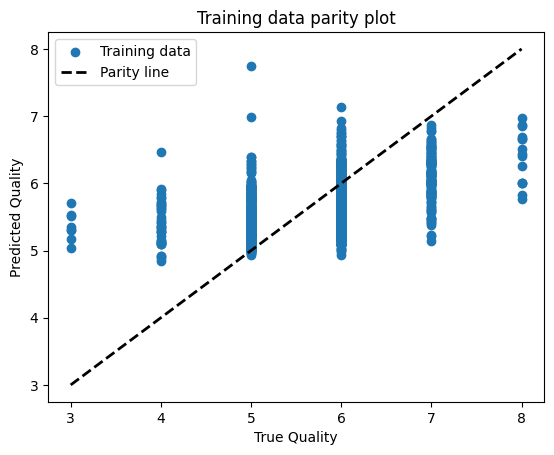

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# define a function to calculate all metrics
def print_metrics(true_val, pred_val):

  # Calculate evaluation metrics on the training dataset
  mse = mean_squared_error(true_val, pred_val)
  rmse = np.sqrt(mse)
  r2 = r2_score(true_val, pred_val)
  mae = mean_absolute_error(true_val, pred_val)

  print(f"Mean Squared Error (MSE): {mse:.4f}")
  print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
  print(f"R-squared (R2): {r2:.4f}")
  print(f"Mean Absolute Error (MAE): {mae:.4f}")

  return mse, rmse, r2, mae

# define a function to draw a parity plot
def draw_parity_plot(true_val, pred_val, labeltxt):

  plt.scatter(true_val, pred_val, label=labeltxt)
  # draw a parity line
  plt.plot([true_val.min(), true_val.max()], [true_val.min(), true_val.max()], 'k--', lw=2, label='Parity line')
  plt.xlabel('True Quality')
  plt.ylabel('Predicted Quality')
  plt.title(labeltxt+ ' parity plot')
  plt.legend()
  plt.show()


# Evaluate the model on the training data first to see how well the
#   model fits the training data
y_train_pred = linreg.predict(X_train_scaled)
mse, rmse, r2, mae = print_metrics(y_train, y_train_pred)

# let's also make a parity plot
draw_parity_plot(y_train, y_train_pred, 'Training data')





Mean Squared Error (MSE): 0.4919
Root Mean Squared Error (RMSE): 0.7013
R-squared (R2): 0.2615
Mean Absolute Error (MAE): 0.5312


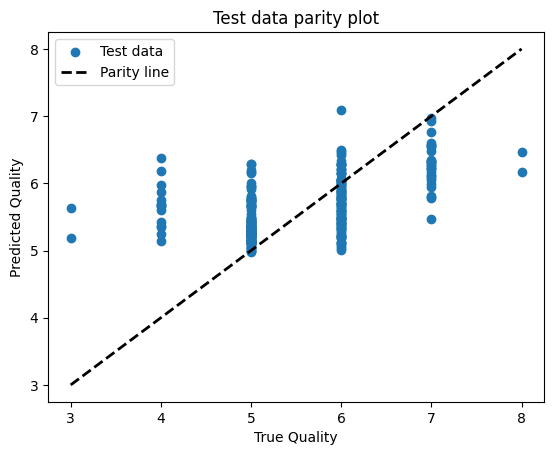

In [ ]:
# Evaluate the model on the test data
y_test_pred = linreg.predict(X_test_scaled)
mse, rmse, r2, mae = print_metrics(y_test, y_test_pred)

# draw a parity plot
draw_parity_plot(y_test, y_test_pred, 'Test data')

### 2.4 Exercise❗
Can we improve model predictions by relaxing the constrains for non-negative coefficients? Write code to check.

Mean Squared Error (MSE): 0.4275
Root Mean Squared Error (RMSE): 0.6539
R-squared (R2): 0.3706
Mean Absolute Error (MAE): 0.5082


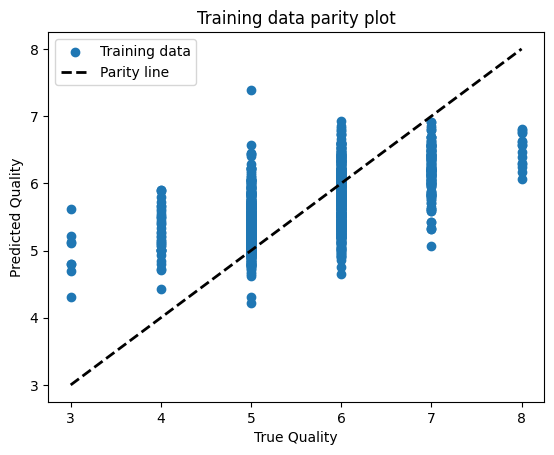

Mean Squared Error (MSE): 0.4534
Root Mean Squared Error (RMSE): 0.6734
R-squared (R2): 0.3193
Mean Absolute Error (MAE): 0.5112


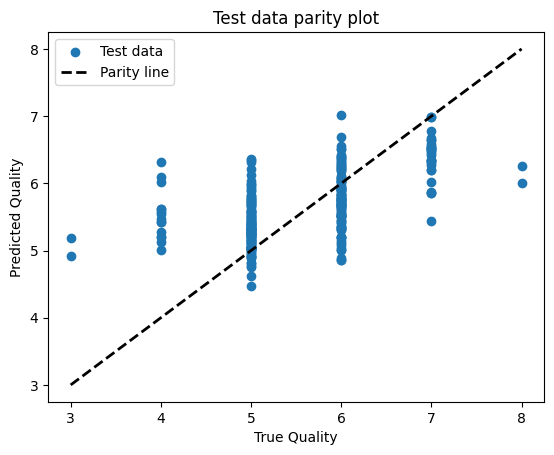

In [ ]:
# @title Sample Code
# Create a Linear Regression model without enforcing positive coefficients
linreg = LinearRegression(fit_intercept=True, positive=False)

# Fit the model to the training data
linreg.fit(X_train_scaled, y_train)

# make both parity plots for training set and test set
y_train_pred = linreg.predict(X_train_scaled)
mse, rmse, r2, mae = print_metrics(y_train, y_train_pred)
draw_parity_plot(y_train, y_train_pred, 'Training data')

y_test_pred = linreg.predict(X_test_scaled)
mse, rmse, r2, mae = print_metrics(y_test, y_test_pred)
draw_parity_plot(y_test, y_test_pred, 'Test data')

## 3. Least Absolute Shrinkage and Selection Operator (LASSO)

### 3.1 An Example of Model Overfitting

When training set is small or there are many features (or degrees of freedom), the model tends to overfit - that is a model tries to memorize the training set so closely that the model fails to make correct predictions on new data. An overfit model is analogous to an invention that performs well in the lab but is worthless in the real world.

Generalization is the opposite of overfitting. That is, a model that generalizes well makes good predictions on new data. Our goal is to create a model that generalizes well to new data.

Let's try to see how an overfit model looks like.

Let's re-create training and test sets, but this time let's intentionally assign a small training set.

In [ ]:
# data spliting into training and testing, set random state to ensure reproducibility
df_train_small,df_test_large = train_test_split(wine_unique, train_size=0.1,test_size=0.9,random_state=100)

In [ ]:
df_train_small.info()

<class 'pandas.core.frame.DataFrame'>
Index: 135 entries, 148 to 792
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         135 non-null    float64
 1   volatile acidity      135 non-null    float64
 2   citric acid           135 non-null    float64
 3   residual sugar        135 non-null    float64
 4   chlorides             135 non-null    float64
 5   free sulfur dioxide   135 non-null    float64
 6   total sulfur dioxide  135 non-null    float64
 7   density               135 non-null    float64
 8   pH                    135 non-null    float64
 9   sulphates             135 non-null    float64
 10  alcohol               135 non-null    float64
 11  quality               135 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 13.7 KB


In [ ]:
# Separate features (X) and target (y)
X_train_small = df_train_small.drop('quality', axis=1)
y_train_small = df_train_small['quality']
X_test_large = df_test_large.drop('quality', axis=1)
y_test_large = df_test_large['quality']

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit on training data only (to avoid data leakage), transform testing
X_train_small_scaled = scaler.fit_transform(X_train_small)
X_test_large_scaled = scaler.transform(X_test_large)

# Optionally, convert back to DataFrame for convenience
X_train_small_scaled = pd.DataFrame(X_train_small_scaled, columns=X_train_small.columns, index=X_train_small.index)
X_test_large_scaled = pd.DataFrame(X_test_large_scaled, columns=X_test_large.columns, index=X_test_large.index)

In [ ]:
# Create a Linear Regression model
linreg = LinearRegression(fit_intercept=True, positive=False)

# Fit the model to the training data
linreg.fit(X_train_small_scaled, y_train_small)

LinearRegression()

In [ ]:
# evaluate the new model
y_train_small_pred = linreg.predict(X_train_small_scaled)
print('---- Training metrics ----')
_ = print_metrics(y_train_small, y_train_small_pred)
print('---- Test metrics ----')
y_test_large_pred = linreg.predict(X_test_large_scaled)
_ = print_metrics(y_test_large, y_test_large_pred)

---- Training metrics ----
Mean Squared Error (MSE): 0.3642
Root Mean Squared Error (RMSE): 0.6035
R-squared (R2): 0.5369
Mean Absolute Error (MAE): 0.4962
---- Test metrics ----
Mean Squared Error (MSE): 0.4998
Root Mean Squared Error (RMSE): 0.7070
R-squared (R2): 0.2484
Mean Absolute Error (MAE): 0.5421


We can clearly see that $R^2$ is higher (0.54) and MSE is lower (0.36) on the training set than $R^2$ (0.25) and MSE (0.5) on the unseen test set, respectively. This is a strong sign of model overfitting to the training data. Below is a nice illustration for underfit, fit, and overfit models:

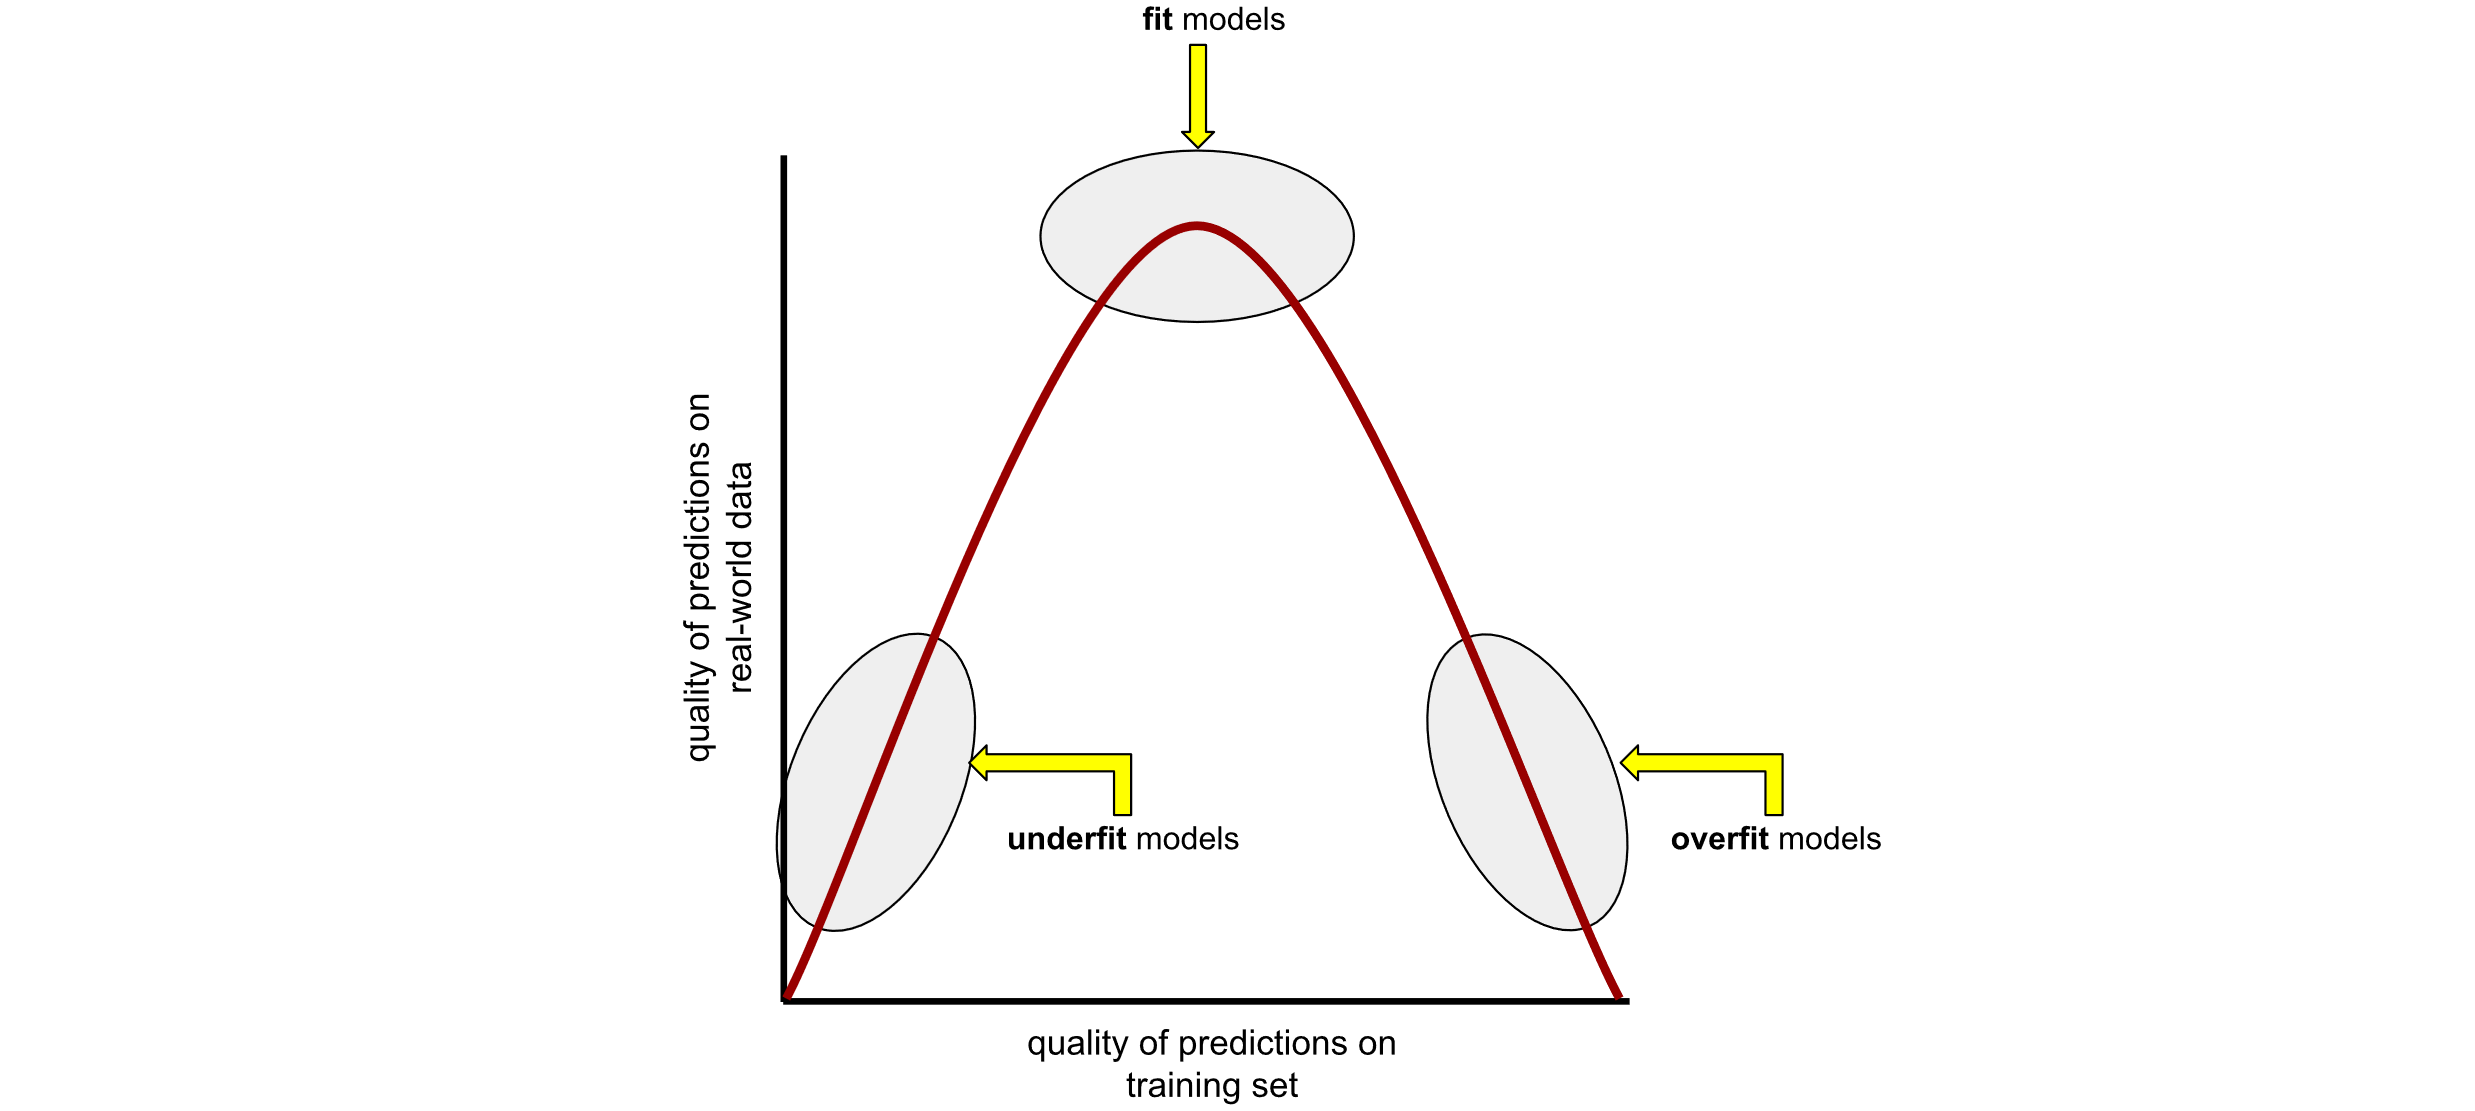

### 3.2 L1 Regularization in LASSO Regression

Regularization is a technique used in machine learning to prevent overfitting and improve the generalization ability of a model. It does this by adding a penalty term to the loss function that the model minimizes during training. This penalty discourages the model from assigning overly large weights to features, which can happen when the model tries to fit the training data too perfectly.

**LASSO** is a type of linear regression that uses L1 regularization. The loss function for LASSO regression is the averaged sum of the squared residuals (same as ordinary linear regression) plus the absolute value of the coefficients multiplied by a regularization parameter, $\alpha$:

$$
L(\mathbf{y}, \hat{\mathbf{y}}) = \frac{1}{2n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} |\beta_j|
$$

where:

- $\frac{1}{2n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$ is the mean squared error (MSE) term, which measures how well the model fits the data.
- $\alpha \sum_{j=1}^{p} |\beta_j|$ is the L1 regularization term, where $\alpha$ is the regularization parameter (a hyperparameter) and $\beta_j$ are the model coefficients.

The $\alpha$ parameter controls the strength of the regularization.
- When $\alpha = 0$, the LASSO model is equivalent to ordinary linear regression.
- As $\alpha$ increases, the regularization penalty becomes stronger, forcing more coefficients to become exactly zero (i.e., reducing the model complexity and thus reducing the overfitting). This has the effect of feature selection, as features with zero coefficients are effectively removed from the model.By shrinking some coefficients to zero, LASSO creates a sparse model that is easier to interpret and can be more robust to noisy data.



Now, let's visualize the effect of $\alpha$ on the fitting quality. When you play with the slider bar, a few things to consider:
- Compare MSEs at the lowest $\alpha$ value to those from ordinary linear regression in Sec. 2.2.1 (limiting behavior of LASSO).
- What happens to MSEs (for both training and testing) when $\alpha$ is increasing?
- What's the optimal $\alpha$ value in your opinion?

In [ ]:
from ipywidgets import interact, FloatSlider
from sklearn.linear_model import Lasso

# Store results for plotting
train_mse_scores = []
test_mse_scores = []
alphas_list = []

# Define a function to train and evaluate Lasso for a given alpha
def train_and_evaluate_lasso_mse(log_alpha):
    alpha = 10**log_alpha  # Convert log_alpha back to alpha
    # Create a Lasso model with the specified alpha
    lasso = Lasso(alpha=alpha, fit_intercept=True, max_iter=30000,
                  positive=False, random_state=100)

    # Fit the model to the small training data
    lasso.fit(X_train_small_scaled, y_train_small)

    # Evaluate the model on the small training data
    y_train_small_pred = lasso.predict(X_train_small_scaled)
    train_mse = mean_squared_error(y_train_small, y_train_small_pred)

    # Evaluate the model on the large test data
    y_test_large_pred = lasso.predict(X_test_large_scaled)
    test_mse = mean_squared_error(y_test_large, y_test_large_pred)

    # Append scores for plotting
    train_mse_scores.append(train_mse)
    test_mse_scores.append(test_mse)
    alphas_list.append(log_alpha)

    # Clear previous plot and draw new one
    plt.figure(figsize=(10, 6))
    plt.scatter(alphas_list, train_mse_scores, label='Training MSE')
    plt.scatter(alphas_list, test_mse_scores, label='Test MSE')
    plt.xlabel('log(Alpha)')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.title('Effect of Alpha on MSE for Lasso Regression')
    #plt.yscale('log')
    plt.legend()
    plt.grid(True)
    plt.show()

# Create a slider for the log of the alpha parameter
# Choose a range for alpha and convert to log scale for the slider
log_alpha_slider = FloatSlider(min=-10.0, max=3.0, step=0.1, value=-1.0, description='log(Alpha):')

# Create an interactive display
interact(train_and_evaluate_lasso_mse, log_alpha=log_alpha_slider);

interactive(children=(FloatSlider(value=-1.0, description='log(Alpha):', max=3.0, min=-10.0), Output()), _dom_…

### 3.3 Automatically Determine $\alpha$ Using k-Fold Cross-Validation

In the previous section, we found the optimal $\alpha$ by manual selection and visualization. In practice, we should not touch the test set before finalizing the model, but instead, we can use the validation set to adjust model's hyperparameters (e.g., $\alpha$ here).

To efficiently use the limited dataset and build a robust model that does not depend on a particular data split, we will use **k-fold cross-validation** (k=5 or 10 typically) to determine the optimal $\alpha$ automatically (review the lecture slides).


Here let's use the 5-fold cross-validation to determine the optimal $\alpha$:


Optimal alpha found via 5-fold cross-validation: 0.0242
Optimal log10(alpha) found via 5-fold cross-validation: -1.6162


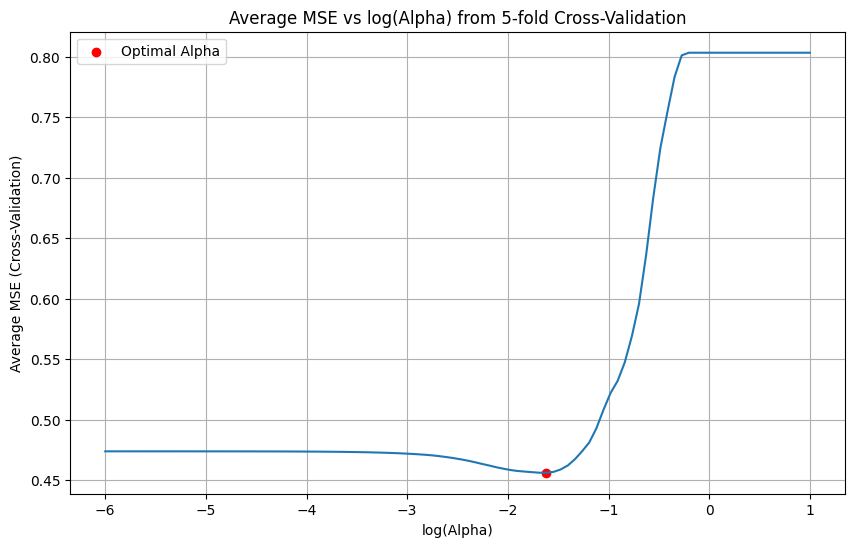

In [ ]:
from sklearn.model_selection import KFold

# Initialize 5-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=100)

# Define a range of alpha values to test
alphas = np.logspace(-6, 1, 100)

# Store MSE for each alpha across all folds in a dictionary
mse_scores = {alpha: [] for alpha in alphas}

# Perform k-fold cross-validation
for fold, (train_index, val_index) in enumerate(kf.split(X_train_small_scaled)):

    # Split data into training and validation sets for this fold
    X_train_fold, X_val_fold = X_train_small_scaled.iloc[train_index], X_train_small_scaled.iloc[val_index]
    y_train_fold, y_val_fold = y_train_small.iloc[train_index], y_train_small.iloc[val_index]

    # Iterate over each alpha value
    for alpha in alphas:
        # Create and train Lasso model
        lasso = Lasso(alpha=alpha, fit_intercept=True, max_iter=30000,
                      positive=False, random_state=100)
        lasso.fit(X_train_fold, y_train_fold)

        # Predict on the validation set
        y_val_pred = lasso.predict(X_val_fold)

        # Calculate MSE and store it
        mse = mean_squared_error(y_val_fold, y_val_pred)
        mse_scores[alpha].append(mse)

        # Q: what's the length of the list for each alpha in the dictionary mse_scores?

# Calculate the average MSE for each alpha across all folds
average_mse = {alpha: np.mean(scores) for alpha, scores in mse_scores.items()}

# Find the optimal alpha with the minimum average MSE
optimal_alpha = min(average_mse, key=average_mse.get)
print(f"\nOptimal alpha found via 5-fold cross-validation: {optimal_alpha:.4f}")
# also print its log10 value
print(f"Optimal log10(alpha) found via 5-fold cross-validation: {np.log10(optimal_alpha):.4f}")

# Optional: Plot average MSE vs log(alpha) to visualize
plt.figure(figsize=(10, 6))
plt.plot(np.log10(list(average_mse.keys())), list(average_mse.values()))
# also plot the optimal alpha in the plot
plt.scatter(np.log10(optimal_alpha), average_mse[optimal_alpha], color='red', label='Optimal Alpha')
plt.xlabel('log(Alpha)')
plt.ylabel('Average MSE (Cross-Validation)')
plt.title('Average MSE vs log(Alpha) from 5-fold Cross-Validation')
plt.legend()
plt.grid(True)
plt.show()

Now let's re-train the LASSO model using the optimal $\alpha$ value found via 5-fold cross-validation above, and see how model performs on unseen dataset:

In [ ]:
# Re-train Lasso model using the optimal alpha value
lasso = Lasso(alpha=optimal_alpha,
              fit_intercept=True, max_iter=30000,
              positive=False, random_state=100)
lasso.fit(X_train_small_scaled, y_train_small)

# evaluate the new model
y_train_small_pred = lasso.predict(X_train_small_scaled)
print('---- Training metrics ----')
_ = print_metrics(y_train_small, y_train_small_pred)
print('---- Test metrics ----')
y_test_large_pred = lasso.predict(X_test_large_scaled)
_ = print_metrics(y_test_large, y_test_large_pred)

---- Training metrics ----
Mean Squared Error (MSE): 0.3745
Root Mean Squared Error (RMSE): 0.6120
R-squared (R2): 0.5237
Mean Absolute Error (MAE): 0.5094
---- Test metrics ----
Mean Squared Error (MSE): 0.4701
Root Mean Squared Error (RMSE): 0.6856
R-squared (R2): 0.2931
Mean Absolute Error (MAE): 0.5236


After applying L1 regularization in LASSO, we find:

* **Training metrics:** MSE increases from 0.3642 (OLR) to 0.3745 (LASSO), and $R^2$ decreases from 0.5369 (OLR) to 0.5237 (LASSO), indicating degraded fitting quality on training data.
* **Testing metrics:** MSE descreases from 0.4998 (OLR) to 0.4701 (LASSO), and $R^2$ increases from 0.2484 (OLR) to 0.2931 (LASSO), indicating improved generalization of model to unseen dataset (less overfit to training).


### 3.4 Final Model
What we just saw is an extreme case where fewer training data are available. Now, let's build a final LASSO model using 80% training and 20% testing data, with regularization parameter determined from 5-fold cross-validation. We combine the above code together:

In [ ]:
# ================ 5-fold cross-validation ==================
# ================ Same code from Sec. 2.2.3 ================
# Initialize 5-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=100)

# Define a range of alpha values to test
alphas = np.logspace(-6, 1, 100)

# Store MSE for each alpha across all folds in a dictionary
mse_scores = {alpha: [] for alpha in alphas}

# Perform k-fold cross-validation
for fold, (train_index, val_index) in enumerate(kf.split(X_train_scaled)):

    # Split data into training and validation sets for this fold
    X_train_fold, X_val_fold = X_train_scaled.iloc[train_index], X_train_scaled.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Iterate over each alpha value
    for alpha in alphas:
        # Create and train Lasso model
        lasso = Lasso(alpha=alpha, fit_intercept=True, max_iter=30000,
                      positive=False, random_state=100)
        lasso.fit(X_train_fold, y_train_fold)

        # Predict on the validation set
        y_val_pred = lasso.predict(X_val_fold)

        # Calculate MSE and store it
        mse = mean_squared_error(y_val_fold, y_val_pred)
        mse_scores[alpha].append(mse)

        # Q: what's the length of the list for each alpha in the dictionary mse_scores?

# Calculate the average MSE for each alpha across all folds
average_mse = {alpha: np.mean(scores) for alpha, scores in mse_scores.items()}

# Find the optimal alpha with the minimum average MSE
optimal_alpha = min(average_mse, key=average_mse.get)

# ================ LASSO fitting ===================
lasso = Lasso(alpha=optimal_alpha,
              fit_intercept=True, max_iter=30000,
              positive=False, random_state=100)
lasso.fit(X_train_scaled, y_train)

# evaluate the new model
y_train_pred = lasso.predict(X_train_scaled)
print('---- Training metrics ----')
_ = print_metrics(y_train, y_train_pred)
print('---- Test metrics ----')
y_test_pred = lasso.predict(X_test_scaled)
_ = print_metrics(y_test, y_test_pred)

---- Training metrics ----
Mean Squared Error (MSE): 0.4284
Root Mean Squared Error (RMSE): 0.6546
R-squared (R2): 0.3693
Mean Absolute Error (MAE): 0.5093
---- Test metrics ----
Mean Squared Error (MSE): 0.4533
Root Mean Squared Error (RMSE): 0.6733
R-squared (R2): 0.3194
Mean Absolute Error (MAE): 0.5122


Compared to OLR, LASSO model generalizes better to unseen data. The following table compares both models' performance on the same test set:

| Metric | OLR   | LASSO |
|--------|-------|-------|
| Mean Squared Error (MSE) | 0.4919 | 0.4533 |
| Root Mean Squared Error (RMSE) | 0.7013 | 0.6733 |
| R-squared (R²) | 0.2615 | 0.3194 |
| Mean Absolute Error (MAE) | 0.5312 | 0.5122 |


### 3.5 Model Interpretation
In addition to building a predictive model, using ML to better understand fundamental science is arguably more important. One fundamental question is: Which factors contribute positively to wine quality, and which factors detract from it?

Linear regression models are powerful because it is intrinsically interpretable, that is we can understand the effect of each feature from the trained coefficients (weights).

Let's visualize the weights of LASSO model:

In [ ]:
import plotly.express as px

# Get the coefficients and feature names from the trained lasso model
coefficients = lasso.coef_
feature_names = X_train_scaled.columns

# Create a pandas DataFrame for Plotly
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient Value': coefficients})

# Create an interactive bar plot using Plotly Express
fig = px.bar(coef_df, x='Feature', y='Coefficient Value',
             title='LASSO Model Coefficients')

# Rotate x-axis labels for better readability
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.update_xaxes(tickangle=-45)

fig.show()

Observation and confirmation:
* Higher alcohol boosts wine structure, mouthfeel, and brings out flavors that enhance perceived quality in red wines.
* Small (moderate) sulphate $SO_4^{2-}$ helps maintain wine color and protect against oxidation, supporting good quality. Excessive sulphates can negatively affect taste—high sulphate dries and acidifies wine.
* High levels of Chlorides $Cl^-$ give wine a noticeable salty taste, which is almost always considered off-putting in quality wine assessment




Let's validate the insights learned from model by making some scatter plots:

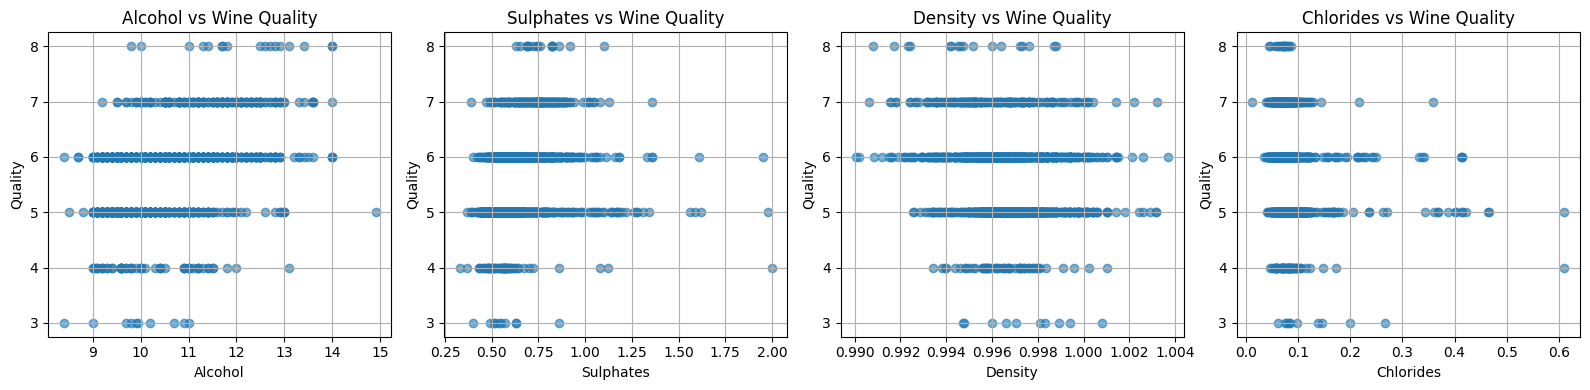

In [ ]:
# Create a figure with four subplots in one row
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Plot Alcohol vs Quality
axes[0].scatter(wine_unique['alcohol'], wine_unique['quality'], alpha=0.6)
axes[0].set_title('Alcohol vs Wine Quality')
axes[0].set_xlabel('Alcohol')
axes[0].set_ylabel('Quality')
axes[0].grid(True)


# Plot Sulphates vs Quality
axes[1].scatter(wine_unique['sulphates'], wine_unique['quality'], alpha=0.6)
axes[1].set_title('Sulphates vs Wine Quality')
axes[1].set_xlabel('Sulphates')
axes[1].set_ylabel('Quality')
axes[1].grid(True)


# Plot Density vs Quality
axes[2].scatter(wine_unique['density'], wine_unique['quality'], alpha=0.6)
axes[2].set_title('Density vs Wine Quality')
axes[2].set_xlabel('Density')
axes[2].set_ylabel('Quality')
axes[2].grid(True)

# Plot Chlorides vs Quality
axes[3].scatter(wine_unique['chlorides'], wine_unique['quality'], alpha=0.6)
axes[3].set_title('Chlorides vs Wine Quality')
axes[3].set_xlabel('Chlorides')
axes[3].set_ylabel('Quality')
axes[3].grid(True)

plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

Discussions:
* In certain range, sulphates positively contributes, but excess amount would decrease the quality. Data imbalance.
* Apparent non-linear behavior.
* Noisy features.

We should be generally cautious about overinterpreting the LASSO coefficients, because:
- A larger LASSO coefficient may not necessarily indicate that the corresponding feature is more important than the others in the prediction. Different feature normalization methods will not affect the model's overall prediction but may alter the coefficients significantly.
- For highly collinear features, the LASSO regression may randomly select one of them (typically the first one enters the model) and shrink the coefficients of the rest. In this sense, it is hard to say one feature is more important than other correlated features. This problem may be solved by preprocessing features with principle component analysis (which will be introduced later in this course) to form a compact and independent feature set .

### 3.6 Exercise ❗
Check how the learned coefficients in LASSO would change if you use linear scaling to normalize the features.

Optimal alpha found via 5-fold cross-validation (Linear Scaling): 0.0011


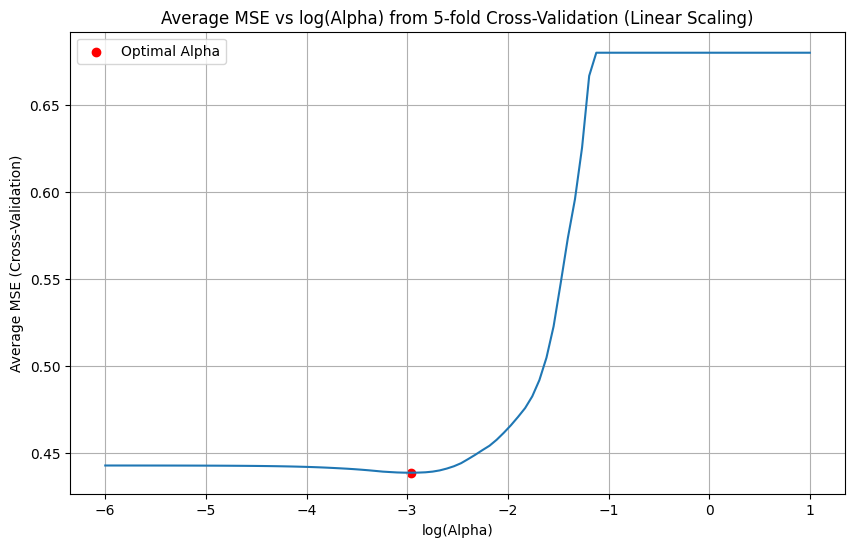

---- Training metrics (Linear Scaling) ----
Mean Squared Error (MSE): 0.4288
Root Mean Squared Error (RMSE): 0.6548
R-squared (R2): 0.3687
Mean Absolute Error (MAE): 0.5096
---- Test metrics (Linear Scaling) ----
Mean Squared Error (MSE): 0.4538
Root Mean Squared Error (RMSE): 0.6736
R-squared (R2): 0.3187
Mean Absolute Error (MAE): 0.5121


In [ ]:
# @title Sample Code
from sklearn.preprocessing import MinMaxScaler

# 1. Scale features with linear scaling
scaler_linear = MinMaxScaler()

# Fit on training data only, transform both training and testing sets
X_train_scaled_linear = scaler_linear.fit_transform(X_train)
X_test_scaled_linear = scaler_linear.transform(X_test)

# Convert back to DataFrame for convenience
X_train_scaled_linear = pd.DataFrame(X_train_scaled_linear, columns=X_train.columns, index=X_train.index)
X_test_scaled_linear = pd.DataFrame(X_test_scaled_linear, columns=X_test.columns, index=X_test.index)

# 2. Using cross validation to find alpha for lasso.
# Initialize 5-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=100)

# Define a range of alpha values to test
alphas = np.logspace(-6, 1, 100)

# Store MSE for each alpha across all folds in a dictionary
mse_scores = {alpha: [] for alpha in alphas}

# Perform k-fold cross-validation
for fold, (train_index, val_index) in enumerate(kf.split(X_train_scaled_linear)):

    # Split data into training and validation sets for this fold
    X_train_fold, X_val_fold = X_train_scaled_linear.iloc[train_index], X_train_scaled_linear.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Iterate over each alpha value
    for alpha in alphas:
        # Create and train Lasso model
        lasso = Lasso(alpha=alpha, fit_intercept=True, max_iter=30000,
                      positive=False, random_state=100)
        lasso.fit(X_train_fold, y_train_fold)

        # Predict on the validation set
        y_val_pred = lasso.predict(X_val_fold)

        # Calculate MSE and store it
        mse = mean_squared_error(y_val_fold, y_val_pred)
        mse_scores[alpha].append(mse)

# Calculate the average MSE for each alpha across all folds
average_mse = {alpha: np.mean(scores) for alpha, scores in mse_scores.items()}

# Find the optimal alpha with the minimum average MSE
optimal_alpha_linear = min(average_mse, key=average_mse.get)
print(f"Optimal alpha found via 5-fold cross-validation (Linear Scaling): {optimal_alpha_linear:.4f}")

# Plot average MSE vs log(alpha) to visualize
plt.figure(figsize=(10, 6))
plt.plot(np.log10(list(average_mse.keys())), list(average_mse.values()))
plt.scatter(np.log10(optimal_alpha_linear), average_mse[optimal_alpha_linear], color='red', label='Optimal Alpha')
plt.xlabel('log(Alpha)')
plt.ylabel('Average MSE (Cross-Validation)')
plt.title('Average MSE vs log(Alpha) from 5-fold Cross-Validation (Linear Scaling)')
plt.legend()
plt.grid(True)
plt.show()


# 3. Fit the lasso with optimal alpha on the full training set (linear scaled)
lasso_linear = Lasso(alpha=optimal_alpha_linear,
                    fit_intercept=True, max_iter=30000,
                    positive=False, random_state=100)
lasso_linear.fit(X_train_scaled_linear, y_train)

# 4. Check the lasso quality on the test set (linear scaled)
y_train_pred_linear = lasso_linear.predict(X_train_scaled_linear)
print('---- Training metrics (Linear Scaling) ----')
_ = print_metrics(y_train, y_train_pred_linear)
print('---- Test metrics (Linear Scaling) ----')
y_test_pred_linear = lasso_linear.predict(X_test_scaled_linear)
_ = print_metrics(y_test, y_test_pred_linear)

# 5. Visualize the learned coefficients
coefficients_linear = lasso_linear.coef_
feature_names = X_train_scaled_linear.columns

coef_df_linear = pd.DataFrame({'Feature': feature_names, 'Coefficient Value': coefficients_linear})

fig_linear = px.bar(coef_df_linear, x='Feature', y='Coefficient Value',
             title='LASSO Model Coefficients (Linear Scaling)')

fig_linear.update_layout(xaxis={'categoryorder':'total descending'})
fig_linear.update_xaxes(tickangle=-45)

fig_linear.show()

Discussions:
* Weights magnitude changes
* The magnitude relationship between features "fixed acidity" and "free sulfur dioxide" has been reversed.